<a href="https://colab.research.google.com/github/Labannya1038/Machine-Learning/blob/main/Genetic_Algorithm_arrhythmia_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

**Load the Dataset**

In [5]:
import pandas as pd

# URL for the Arrhythmia dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/arrhythmia/arrhythmia.data"

# load dataset (no headers in this file)
df = pd.read_csv(url, header=None)

# show shape
print("Dataset Shape:", df.shape)

# preview data
df.head()

Dataset Shape: (452, 280)


,0,1,2,3,4,5,6,7,8,9,...,270,271,272,273,274,275,276,277,278,279
0,75,0,190,80,91,193,371,174,121,-16,...,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4,8
1,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
2,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10
3,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1
4,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7


**Define Neural Network Structure**

In [13]:
# Replace '?' with NaN and convert to numeric for the entire DataFrame
df = df.replace('?', np.nan)
df = df.apply(pd.to_numeric, errors='coerce')

# Fill NaN values (e.g., with the mean of each column)
df = df.fillna(df.mean())

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

input_size = X.shape[1]
hidden_size = 5
output_size = 1

**Helper Functions**

In [19]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def forward_pass(X, weights1, weights2):
    # Ensure X is a NumPy array for matrix multiplication
    X_np = X.to_numpy() if hasattr(X, 'to_numpy') else X
    # Explicitly cast to float to prevent any type issues with np.dot
    X_np = X_np.astype(float)
    hidden_input = np.dot(X_np, weights1)
    hidden_output = sigmoid(hidden_input)
    output_input = np.dot(hidden_output, weights2)
    output = sigmoid(output_input)
    return output

**Define Fitness Function**

In [8]:
def compute_fitness(weights):
    predictions = forward_pass(X_train, weights['w1'], weights['w2'])
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_train, predictions)
    return accuracy

**Initialize Population**

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

population_size = 20
population = []
for _ in range(population_size):
    individual = {
        'w1': np.random.randn(input_size, hidden_size),
        'w2': np.random.randn(hidden_size, output_size)
    }
    population.append(individual)

Generation 1, Best Fitness: 0.6400
Generation 2, Best Fitness: 0.5375
Generation 3, Best Fitness: 0.5275
Generation 4, Best Fitness: 0.5150
Generation 5, Best Fitness: 0.5150
Generation 6, Best Fitness: 0.5150
Generation 7, Best Fitness: 0.5150
Generation 8, Best Fitness: 0.5150
Generation 9, Best Fitness: 0.5150
Generation 10, Best Fitness: 0.5150
Generation 11, Best Fitness: 0.5150
Generation 12, Best Fitness: 0.5150
Generation 13, Best Fitness: 0.5150
Generation 14, Best Fitness: 0.5150
Generation 15, Best Fitness: 0.5150
Generation 16, Best Fitness: 0.5150
Generation 17, Best Fitness: 0.5150
Generation 18, Best Fitness: 0.5150
Generation 19, Best Fitness: 0.5150
Generation 20, Best Fitness: 0.5150
Generation 21, Best Fitness: 0.5150
Generation 22, Best Fitness: 0.5150
Generation 23, Best Fitness: 0.5150
Generation 24, Best Fitness: 0.5150
Generation 25, Best Fitness: 0.5150
Generation 26, Best Fitness: 0.5150
Generation 27, Best Fitness: 0.5150
Generation 28, Best Fitness: 0.5150
G

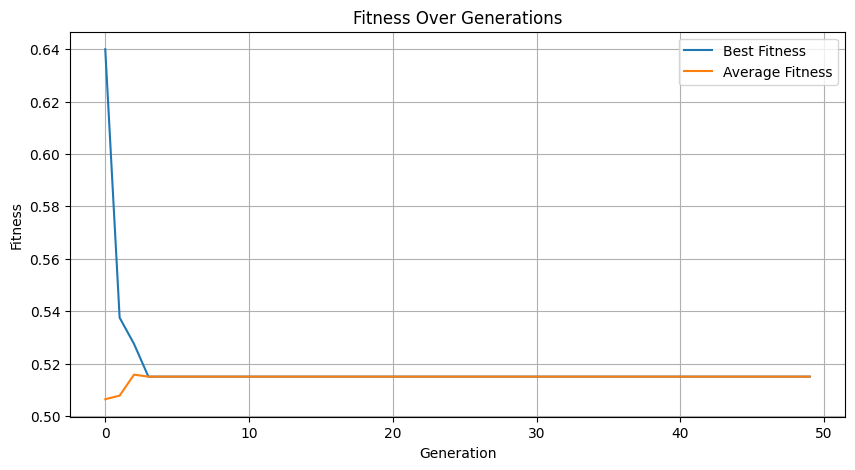

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Creating a sample dataset
X, y = make_classification(n_samples=500, n_features=10, n_informative=8, n_classes=2)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

# Neural Network Structure
input_size = X.shape[1]
hidden_size = 5
output_size = 1

# Helper functions for the Neural Network
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def forward_pass(X, weights1, weights2):
    hidden_input = np.dot(X, weights1)
    hidden_output = sigmoid(hidden_input)
    output_input = np.dot(hidden_output, weights2)
    output = sigmoid(output_input)
    return output

def compute_fitness(weights):
    predictions = forward_pass(X_train, weights['w1'], weights['w2'])
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_train, predictions)
    return accuracy

# Genetic Algorithm Parameters
population_size = 20
generations = 50
mutation_rate = 0.1

# Initialize Population
population = []
for _ in range(population_size):
    individual = {
        'w1': np.random.randn(input_size, hidden_size),
        'w2': np.random.randn(hidden_size, output_size)
    }
    population.append(individual)

# Tracking performance
best_fitness_history = []
average_fitness_history = []

# Main Genetic Algorithm Loop
for generation in range(generations):
    # Evaluate Fitness of each Individual
    fitness_scores = np.array([compute_fitness(individual) for individual in population])
    best_fitness = np.max(fitness_scores)
    average_fitness = np.mean(fitness_scores)
    best_fitness_history.append(best_fitness)
    average_fitness_history.append(average_fitness)

    # Selection: Select top half of the population
    sorted_indices = np.argsort(fitness_scores)[::-1]
    population = [population[i] for i in sorted_indices[:population_size//2]]

    # Crossover and Mutation
    new_population = []
    while len(new_population) < population_size:
        parents = np.random.choice(population, 2, replace=False)
        child = {
            'w1': (parents[0]['w1'] + parents[1]['w1']) / 2,
            'w2': (parents[0]['w2'] + parents[1]['w2']) / 2
        }

        # Mutation
        if np.random.rand() < mutation_rate:
            child['w1'] += np.random.randn(*child['w1'].shape) * 0.1
            child['w2'] += np.random.randn(*child['w2'].shape) * 0.1

        new_population.append(child)

    population = new_population

    print(f"Generation {generation+1}, Best Fitness: {best_fitness:.4f}")

# Evaluate the best individual on validation set
best_individual = population[np.argmax(fitness_scores)]
predictions = forward_pass(X_val, best_individual['w1'], best_individual['w2'])
predictions = (predictions > 0.5).astype(int)
final_accuracy = accuracy_score(y_val, predictions)
print(f"Final Accuracy on Validation Set: {final_accuracy:.4f}")

# Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(best_fitness_history, label='Best Fitness')
plt.plot(average_fitness_history, label='Average Fitness')
plt.title('Fitness Over Generations')
plt.xlabel('Generation')
plt.ylabel('Fitness')
plt.legend()
plt.grid(True)
plt.show()